In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import glob

In [3]:
ImgMoscow_r = cv2.imread('moscow_r.jpeg')
ImgMoscow_r = cv2.cvtColor(ImgMoscow_r, cv2.COLOR_BGR2RGB)

ImgMoscow_r_turn = cv2.imread('moscow_r_turn.jpeg')
ImgMoscow_r_turn = cv2.cvtColor(ImgMoscow_r_turn, cv2.COLOR_BGR2RGB)

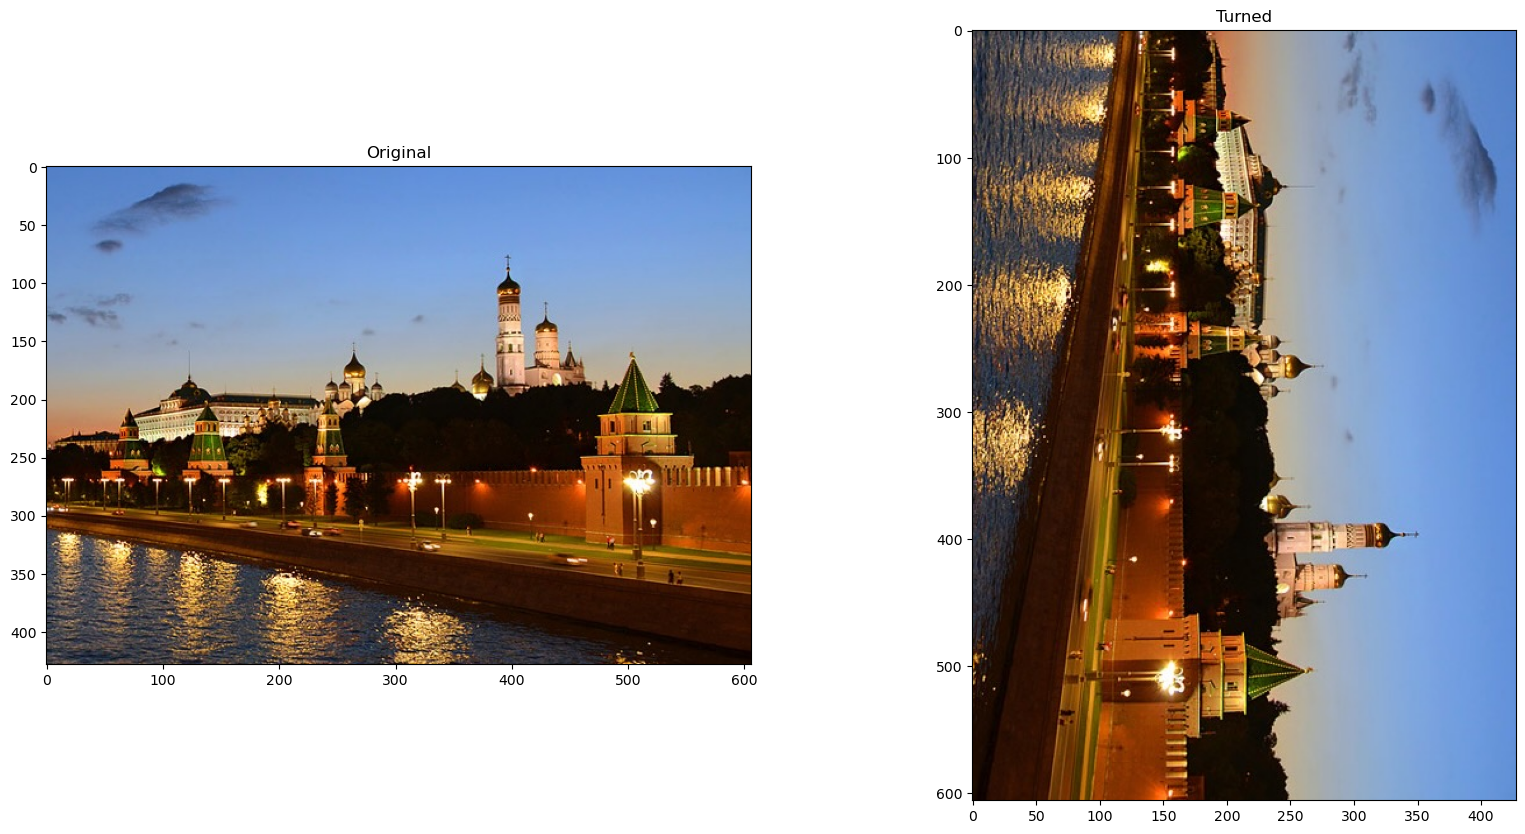

In [4]:
plt.figure(figsize = [20,10])
plt.subplot(121); plt.imshow(ImgMoscow_r); plt.title("Original");
plt.subplot(122); plt.imshow(ImgMoscow_r_turn); plt.title("Turned");

In [5]:
ImgMoscow_r_Gray = cv2.cvtColor(ImgMoscow_r, cv2.COLOR_RGB2GRAY)
ImgMoscow_r_turn_Gray = cv2.cvtColor(ImgMoscow_r_turn, cv2.COLOR_RGB2GRAY)

nMaxFeature = 500000
orb = cv2.ORB_create(nMaxFeature)
keypoints1, descs1 = orb.detectAndCompute(ImgMoscow_r_Gray, None) # keypoint - геометрия, descs - вектор точки
keypoints2, descs2 = orb.detectAndCompute(ImgMoscow_r_turn_Gray, None)

# OrigKey = cv2.drawKeypoints(ImgMoscow_r, keypoints1, outImage=np.array([]), color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
# ToMoveKey = cv2.drawKeypoints(ImgMoscow_r_turn, keypoints2, outImage=np.array([]), color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

In [6]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = matcher.match(descs1, descs2, None)

In [7]:
matches = list(matches)
matches.sort(key = lambda x: x.distance, reverse = False)

# print(len(matches))

nGoodMatches = int(len(matches) * 0.7)
matches = matches[:nGoodMatches]

In [17]:
# imgMatches = cv2.drawMatches(ImgMoscow_r, keypoints1, ImgMoscow_r_turn, keypoints2, matches, None)

# plt.figure(figsize=[18, 15])
# plt.imshow(imgMatches)

In [8]:
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

H, mask = cv2.findHomography(points2, points1, cv2.RANSAC) # RANSAC - оптимальное решение
print(H)

[[ 9.27061033e-04  1.00081830e+00 -1.64309812e-01]
 [-1.00125814e+00 -7.23965085e-05  4.26985902e+02]
 [ 3.64852579e-06  3.43114404e-07  1.00000000e+00]]


In [10]:
h, w, c = ImgMoscow_r.shape
ImgMoscow_res = cv2.warpPerspective(ImgMoscow_r_turn, H, (w, h))

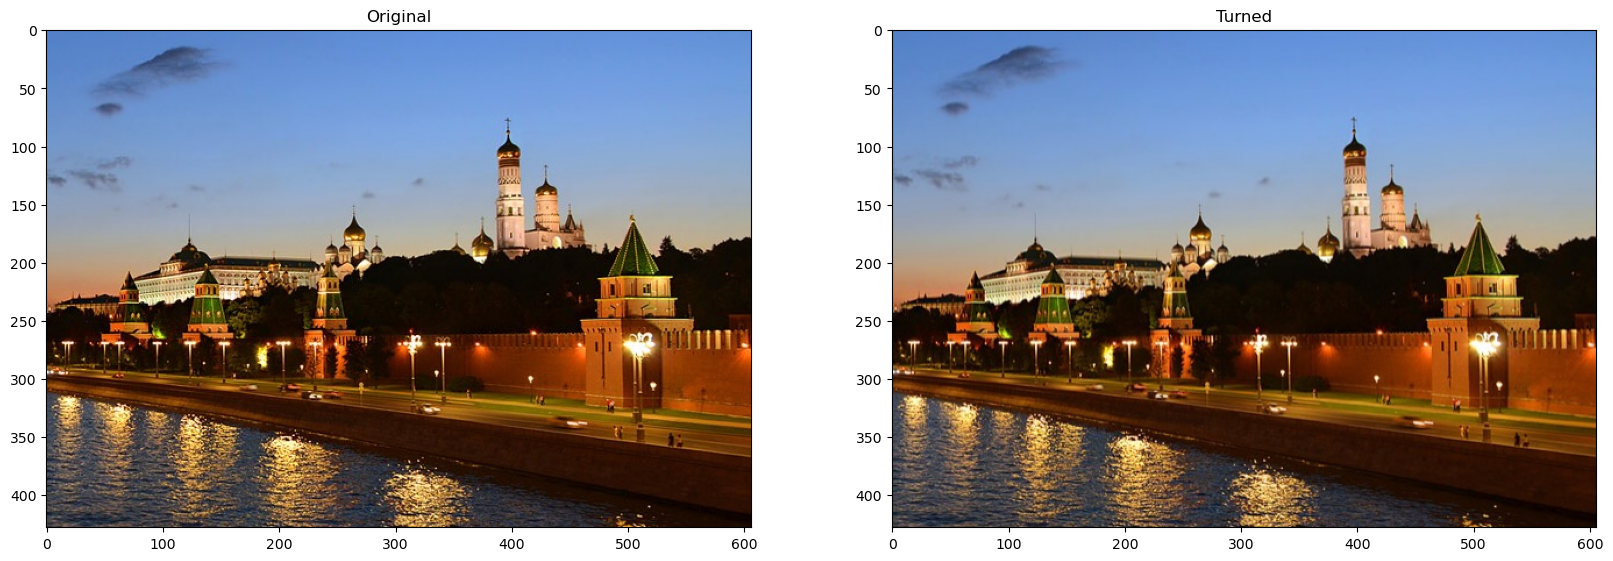

In [11]:
plt.figure(figsize = [20,10])
plt.subplot(121); plt.imshow(ImgMoscow_r); plt.title("Original");
plt.subplot(122); plt.imshow(ImgMoscow_res); plt.title("Turned");

In [12]:
cv2.imwrite("moscow_r_res.png", ImgMoscow_res[:, :, ::-1])

True